In [1]:
import pandas as pd
df=pd.read_csv("custdata.tsv", sep="\t")

In [2]:
df.head()

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
0,2068,F,NaN,11300,Married,True,Homeowner free and clear,False,2.0,49.0,Michigan
1,2073,F,NaN,0,Married,True,Rented,True,3.0,40.0,Florida
2,2848,M,True,4500,Never Married,False,Rented,True,3.0,22.0,Georgia
3,5641,M,True,20000,Never Married,False,Occupied with no rent,False,0.0,22.0,New Mexico
4,6369,F,True,12000,Never Married,True,Rented,True,1.0,31.0,Florida


In [3]:
df.shape

(1000, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   custid        1000 non-null   int64  
 1   sex           1000 non-null   object 
 2   is.employed   672 non-null    object 
 3   income        1000 non-null   int64  
 4   marital.stat  1000 non-null   object 
 5   health.ins    1000 non-null   bool   
 6   housing.type  944 non-null    object 
 7   recent.move   944 non-null    object 
 8   num.vehicles  944 non-null    float64
 9   age           1000 non-null   float64
 10  state.of.res  1000 non-null   object 
dtypes: bool(1), float64(2), int64(2), object(6)
memory usage: 79.2+ KB


In [5]:
df.describe()

,custid,income,num.vehicles,age
count,1.000000e+03,1000.000000,944.000000,1000.000000
mean,6.984997e+05,53504.771000,1.916314,51.699815
std,4.135083e+05,65478.065729,1.101618,18.863433
min,2.068000e+03,-8700.000000,0.000000,0.000000
25%,3.456668e+05,14600.000000,1.000000,38.000000
50%,6.934030e+05,35000.000000,2.000000,50.000000
75%,1.044606e+06,67000.000000,2.000000,64.000000
max,1.414286e+06,615000.000000,6.000000,146.680197


**Initial Observations**

    -   The num.vehicles,housing.type,and recent.move all have a count of 944, but there are 1000 rows, so there may be some missing values. 
    - Also custid is registering as an integer when it may actaully be an object in this case since the mean is not needed here.
    - The is.employed also has missing values since NaN is present and the count is off.

In [6]:
df.isna().sum()

custid            0
sex               0
is.employed     328
income            0
marital.stat      0
health.ins        0
housing.type     56
recent.move      56
num.vehicles     56
age               0
state.of.res      0
dtype: int64

In [7]:
df.shape

(1000, 11)

In [8]:
df=df.dropna(subset=["housing.type"])

In [9]:
df.shape

(944, 11)

In [10]:
df.isna().sum()

custid            0
sex               0
is.employed     280
income            0
marital.stat      0
health.ins        0
housing.type      0
recent.move       0
num.vehicles      0
age               0
state.of.res      0
dtype: int64

In [11]:
df["housing.type"].value_counts()

housing.type
Homeowner with mortgage/loan    412
Rented                          364
Homeowner free and clear        157
Occupied with no rent            11
Name: count, dtype: int64

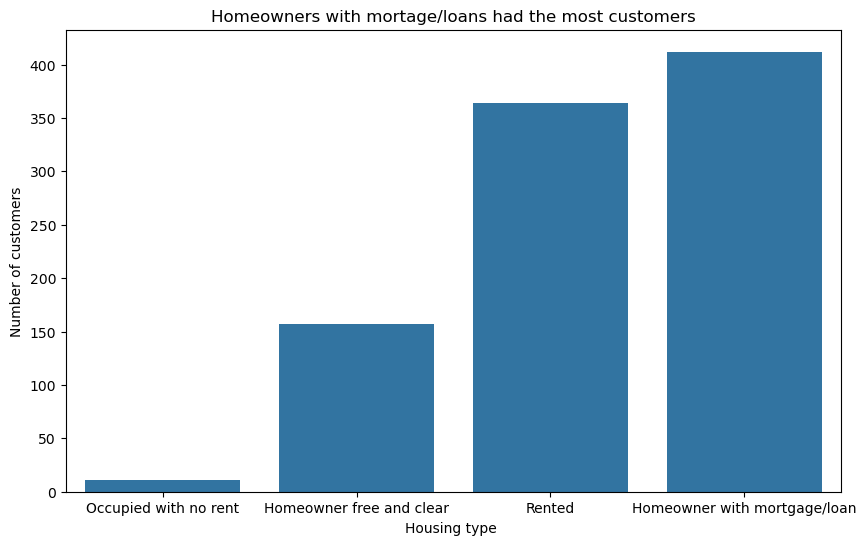

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.countplot(data=df,x="housing.type", order= df["housing.type"].value_counts(ascending=True).index)
plt.title("Homeowners with mortage/loans had the most customers")
plt.xlabel("Housing type ")
plt.ylabel("Number of customers")

plt.show()

**Cleaning Log**

- There was a total of 1000 rows loaded. 
- I decided to delete the 56 rows which had data missing for housing.type since for the data question at hand I'm only interested in comparing housing type.
- Them missing value counts for recent.move and num.vehicles went to 0 also when I deleted the 56 rows, showing their missing values were in the same rows.

https://github.com/jazzminowens/cs82a-portfolio